In [29]:
import networkx as nx
import numpy as np
import string
import matplotlib.pyplot as plt

In [3]:
nameToId : dict[str:int] = {}
idToName : dict[int:str] = {}
with open("allPageRank/nameToId.txt") as f:
    for line in f.readlines():
        nom, w_id = line.split(" :: ")
        nameToId[nom] = int(w_id)
        idToName[int(w_id)] = nom

In [30]:
valles_connections = {}

with open("allPageRank/entriesConnections.txt") as f:
    for line in f.read().split("\n"):
        if line == "": continue
        source, connections = line.split(" :: ")
        if not len(connections) == 0:
            connections = connections.split(" ")
        if int(source) in idToName.keys():
            valles_connections[int(source)] = [int(conn) for conn in connections if not conn == ""]

for (pob, conn) in valles_connections.items():
    valles_connections[pob] = list(filter(lambda x: x in idToName.keys(), conn))

In [53]:
valles_matrix = np.zeros((len(valles_connections), len(valles_connections)))

id_to_pos = {id: i for i, id in enumerate(valles_connections)}
pos_to_id = {i: id for i, id in enumerate(valles_connections)}

print(id_to_pos)
print(id_to_pos[246376])

for (pob, conn) in valles_connections.items():
    if len(conn) == 0: continue
    for dest in conn:
        valles_matrix[id_to_pos[dest]][id_to_pos[pob]] = 1/len(conn)

print(valles_matrix)

{672956: 0, 120555: 1, 128391: 2, 1081939: 3, 215785: 4, 151307: 5, 188559: 6, 193149: 7, 1076542: 8, 205612: 9, 320367: 10, 235989: 11, 236008: 12, 1076057: 13, 1243569: 14, 1075763: 15, 246376: 16, 525838: 17, 1168429: 18, 380006: 19, 733962: 20, 829756: 21, 463930: 22, 704649: 23, 493961: 24, 1080205: 25, 831317: 26, 1078228: 27, 531195: 28, 824591: 29, 680037: 30, 680807: 31, 1060525: 32, 683012: 33, 721636: 34, 733959: 35, 783800: 36, 1082731: 37, 791130: 38, 1083429: 39, 831214: 40, 831781: 41, 906491: 42, 1076325: 43, 1082800: 44, 917333: 45, 963615: 46, 1026143: 47, 1040477: 48, 1054614: 49, 1075408: 50, 1076650: 51, 1079877: 52, 1100291: 53, 1151426: 54, 1218294: 55, 1227536: 56, 1230472: 57, 1230561: 58, 1243695: 59, 1243904: 60}
16
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.14285714 ... 0.         0.         0.        ]
 [0.         0.33333333 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.        

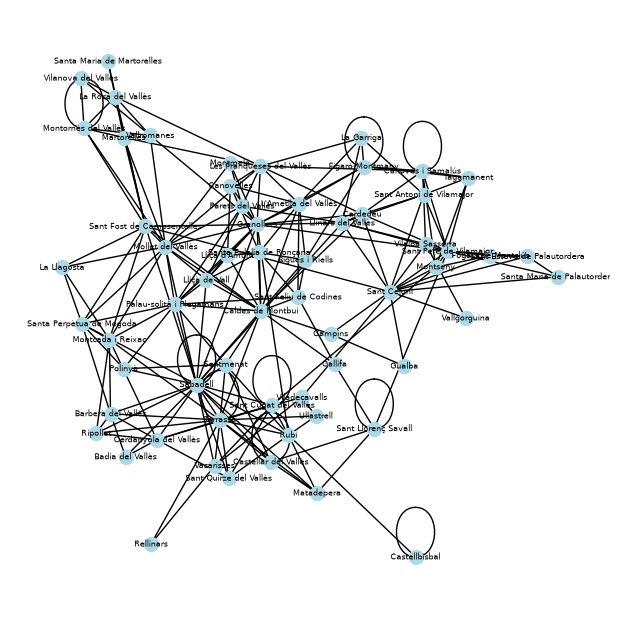

In [54]:
G = nx.from_numpy_array(valles_matrix)

# Dibuixar
plt.figure(figsize=(6, 6))
nx.draw(
    G,
    labels={i: idToName[id] for id, i in id_to_pos.items()},
    with_labels=True,
    node_color="lightblue",
    node_size=100,
    font_size=6
)

plt.show()

In [66]:
alpha = 0.99
N = valles_matrix.shape[0]

damping_matrix = np.ones_like(valles_matrix)/N

M = alpha*valles_matrix + (1-alpha)*damping_matrix

print(M)

[[1.63934426e-04 1.63934426e-04 1.63934426e-04 ... 1.63934426e-04
  1.63934426e-04 1.63934426e-04]
 [1.63934426e-04 1.63934426e-04 1.41592506e-01 ... 1.63934426e-04
  1.63934426e-04 1.63934426e-04]
 [1.63934426e-04 3.30163934e-01 1.63934426e-04 ... 1.63934426e-04
  1.63934426e-04 1.63934426e-04]
 ...
 [1.63934426e-04 1.63934426e-04 1.63934426e-04 ... 1.63934426e-04
  1.63934426e-04 1.63934426e-04]
 [1.63934426e-04 1.63934426e-04 1.63934426e-04 ... 1.63934426e-04
  1.63934426e-04 1.63934426e-04]
 [1.63934426e-04 1.63934426e-04 1.63934426e-04 ... 2.47663934e-01
  1.63934426e-04 1.63934426e-04]]


In [67]:
vaps, veps = np.linalg.eig(M)

print(vaps)


[ 9.97838742e-01+0.00000000e+00j  9.82040948e-01+0.00000000e+00j
  9.90000000e-01+0.00000000e+00j  9.29766409e-01+0.00000000e+00j
  7.56391264e-01+0.00000000e+00j  7.07156541e-01+4.34933545e-02j
  7.07156541e-01-4.34933545e-02j  5.93739597e-01+0.00000000e+00j
 -6.89539842e-01+0.00000000e+00j  4.66885519e-01+1.13676718e-01j
  4.66885519e-01-1.13676718e-01j -5.85101487e-01+0.00000000e+00j
  4.27794698e-01+0.00000000e+00j  4.14250098e-01+0.00000000e+00j
 -4.84215831e-01+0.00000000e+00j -2.93598012e-01+3.02501487e-01j
 -2.93598012e-01-3.02501487e-01j  3.30480554e-01+0.00000000e+00j
  2.83713172e-01+7.87831294e-02j  2.83713172e-01-7.87831294e-02j
  4.44632831e-02+2.87801658e-01j  4.44632831e-02-2.87801658e-01j
 -3.86374909e-01+8.22414209e-02j -3.86374909e-01-8.22414209e-02j
 -2.58510810e-01+1.90038201e-01j -2.58510810e-01-1.90038201e-01j
 -3.63695595e-01+0.00000000e+00j  1.90966377e-01+0.00000000e+00j
  1.56574067e-01+0.00000000e+00j  3.56041342e-02+1.58055105e-01j
  3.56041342e-02-1.580551

In [38]:
def PageRank(graf, p):
    conexions = nx.to_numpy_array(graf)
    arrayDeMatriu = []
    for columnes in conexions: # OBS: Es columnes i no files ja que al fer nx.to_numpy_array es retorna una matriu transposta.
        arrayDeMatriu.append(columnes/sum(columnes)) # Dividim els valors de les columnes (0 ó 1) entre la suma.
    matriu = matrix(arrayDeMatriu) # finalment, la convertim en matriu
    segonQuadrantDeATrans = (1-p)*matriu
    segonYTercerQuadrantDeATrans = segonQuadrantDeATrans.augment(zero_vector(RR, segonQuadrantDeATrans.ncols()))
    segonYTercerQuadrantDeA = segonYTercerQuadrantDeATrans.transpose()
    A = segonYTercerQuadrantDeA.augment(vector([p for _ in range(segonYTercerQuadrantDeA.ncols())] + [1]))
    # Calculem els vectors propis de A amb valor propi 1 (sempre existirà per la forma de la matriu)
    vectorPropi = (A - identity_matrix(A.ncols())).right_kernel().basis()[0] #Sabem que la dimensió 
    vectorPropi /= vectorPropi[-1] # La dividim per el seu ultim valor per aixi tindre com última coordenada 1.
    etiquetesDelGraf = list(graf.nodes())
    etiquetaAPageRang = {etiquetesDelGraf[i]: vectorPropi[i] for i in range(len(graf.nodes()))}
    return etiquetaAPageRang

def ordre(etiquetaAPageRang):
    for i, pag in enumerate(dict(sorted(etiquetaAPageRang.items(), reverse=True, key=lambda item: item[1]))):
        print(f"{i+1}: {pag}")

def dibuix(graf, rot = None, tit = None, etiquetaAPageRang = None, typeof = "shell"):
    typeof = nx.shell_layout(graf, rotate=rot)
    plt.figure()
    plt.gca().set_aspect('equal', adjustable='box')
    if tit is not None:
        plt.title(tit)
    nx.draw_networkx_labels(graf, pos = typeof, font_color="#000000")
    if etiquetaAPageRang is None:
        nx.draw_networkx_nodes(graf, pos = typeof, node_color="#9FDFF6")
    else:
        nx.draw_networkx_nodes(graf, node_size=300*vector(list(map(lambda x: sqrt(x), etiquetaAPageRang.values()))), pos = typeof, node_color="#9FDFF6")
    nx.draw_networkx_edges(graf, pos = typeof, edge_color=list(map(lambda x: x[2], graf.edges.data("color"))))
    plt.tight_layout()
    plt.axis("off")
    plt.show()

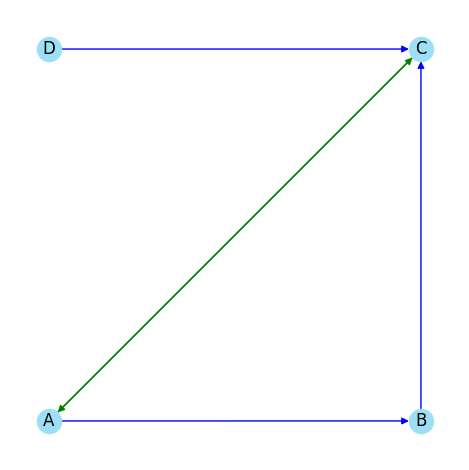

In [4]:
Graf1 = nx.DiGraph()
Graf1.add_nodes_from(range(4))
Graf1.add_edges_from([(0,1),(1,2),(3,2)], color="blue")
Graf1.add_edges_from([(0,2),(2,0)], color="green")
etiquetes1 = dict(zip(Graf1, string.ascii_uppercase)) # Construïm un diccionari per a les etiquetes
Graf1 = nx.relabel_nodes(Graf1, etiquetes1) # Reescrivim les etiquetes
dibuix(Graf1, -2.356194)

In [5]:
PR115 = PageRank(Graf1, 0.15)
PR15 = PageRank(Graf1, 0.5)
show(PR115)
show(PR15)

NameError: name 'matrix' is not defined

In [6]:
print("Per p = 0.15:")
ordre(PR115)
print("Per p = 0.5:")
ordre(PR15)

Per p = 0.15:


NameError: name 'PR115' is not defined

In [7]:
dibuix(Graf1, -2.356194, "p=0.15", PR115)
dibuix(Graf1, -2.356194, "p=0.5", PR15)

NameError: name 'PR115' is not defined

## Amb tot el graf de la Viquipèdia

### Explicació del funcionament del programa
Primer, per compilar getAllConnectionEntries.cpp (i també namesAndIds.cpp) s'ha de fer la comanda `g++ -std=c++17 -I/opt/homebrew/include ./getAllConnectionEntries.cpp -L/opt/homebrew/lib -lzim -o getAllConnectionEntries` i després executar-ho amb `./getAllConnectionEntries ./wikipedia_ca_all_nopic.zim` (ídem en el cas de namesAndIds.cpp). 

Els resultats obtinguts amb aquset programa ja son proporcionats (entriesConnections.txt i nameToID.txt) ja que per fer aixó d'adalt s'hauria de instalar la llibreria zim, que és la que llegeix els fitxers, descarregar el fitxer `wikipedia_ca_all_nopic.zim` i executar el programa (triga aproximadament 15 minuts). És per aixó que els resultats d'aquesta part son proporcionats. 

Després d'alló, només queda fer el PageRank, primer compilar amb `g++ -std=c++17 ./pageRanker.cpp -o pageRanker` i després amb `./pageRanker <factor>` genera un fitxer amb nom `damping<factor*100>.txt` a `resultatsPageRank` amb resultats ordenats de forma ascendent.

Notem com, en els que hem fet nosaltres quant més gran es el dumping factor més triga en convergir (per a un epsilon de 1e-8):

| d    | Iteracions necessàries|
|------|-----------------------|
| 0.5  | 18                    |
| 0.7  | 29                    |
| 0.85 | 52                    |
| 0.99 | 840                   |


### Analisi del subgraf sobre el PageRank del graf complet

In [34]:
from os import listdir

nom_to_pos : dict[str:list[tuple(int,int)]] = {i:[] for i in nameToId} 

for damp in sorted(listdir("allPageRank/resultatsPageRank")):
    print("\nAmb", float(damp[7:-4])/100, "com a factor d'esmorteïment:")
    i = 0
    with open("allPageRank/resultatsPageRank/" + damp) as f:
        for j, line in enumerate(f.readlines()):
            w_id, punt = line.split(": ")
            if int(w_id) in idToName:
                i += 1
                nom_to_pos[idToName[int(w_id)]].append((i,j))
                if i < 6:
                    print(f"\t {i}.- {idToName[int(w_id)]}: {punt[:-1]} (pos {j} del PageRank del graf complet)")

nom_to_pos_invar : dict[str:int] = {}
nom_to_diferencia_pos : dict[str:int] = {}
nom_to_diferencia_glo_pos : dict[str:int] = {}
for nom, posicions in nom_to_pos.items():
    if all(p[0] == posicions[0][0] for p in posicions):
        nom_to_pos_invar[nom] = posicions[0][0]
    else:
        primer = posicions[0][0]
        ultim = posicions[-1][0]
        nom_to_diferencia_pos[nom] = primer-ultim
    # Per la posició de tot el graf
    primer = posicions[0][1]
    ultim = posicions[-1][1]
    nom_to_diferencia_glo_pos[nom] = primer-ultim

print("\nCiutats sense discusió de posició:")
for nom, pos in sorted(nom_to_pos_invar.items(), key=lambda i: i[1]):
    print("\t-",nom,"a", pos)

print("\nCiutats amb més diferencia de posicions:")
for nom, pos in sorted(nom_to_diferencia_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][0], nom_to_pos[nom][-1][0]))

print("\nCiutats amb més diferencia de posicions sobre el global:")
for nom, pos in sorted(nom_to_diferencia_glo_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][1], nom_to_pos[nom][-1][1]))




Amb 0.5 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000106482 (pos 354 del PageRank del graf complet)
	 2.- Terrassa: 7.54056e-05 (pos 589 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 4.46182e-05 (pos 1199 del PageRank del graf complet)
	 4.- Granollers: 3.42856e-05 (pos 1741 del PageRank del graf complet)
	 5.- La Garriga: 2.13281e-05 (pos 3190 del PageRank del graf complet)

Amb 0.7 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000146681 (pos 364 del PageRank del graf complet)
	 2.- Terrassa: 9.73816e-05 (pos 663 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 5.42709e-05 (pos 1486 del PageRank del graf complet)
	 4.- Granollers: 4.24501e-05 (pos 2239 del PageRank del graf complet)
	 5.- La Garriga: 2.38732e-05 (pos 4248 del PageRank del graf complet)

Amb 0.85 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000172196 (pos 377 del PageRank del graf complet)
	 2.- Terrassa: 0.000106695 (pos 811 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 

Podem veure que hi ha diverses posicions que són indiscutibles, com la de Terrassa, Sabadell, Sant Cugat del Vallès i Granollers a les 4 més importants.

També podem veure com altres amb dúmping factor més baix es veuen afavorits, ja que tenen moltes connexions (Bigues i Riells, i Lliçà d'Amunt), mentre d'altres amb el factor més alt es veuen beneficiades (com Sant Quirze del Vallès o Badia del Vallès) perquè tenen connexions amb nodes de qualitat més alta.

Sobretot Lliçà d'Amunt, veiem que segons la Viquipèdia és una de les que més baixa a la posició global pel canvi del factor.

Amb aquesta metodologia Sabadell és la ciutat més important.